In [31]:
import numpy as np
import matplotlib.pyplot as plt

In [32]:
def data_loader(fname):
    
    data = np.loadtxt(fname)
    energy = data[:, 0]
    pdos = data[:, 1]  # ldos col, total contribution for a given orbital
    ppdos = data[:, 2:]

    return energy, pdos, ppdos

<>:68: SyntaxWarning: invalid escape sequence '\G'
<>:68: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_16467/507140144.py:68: SyntaxWarning: invalid escape sequence '\G'
  sym_kpoints_name = ["W", "L", "$\Gamma$", "X", "W", "K"]


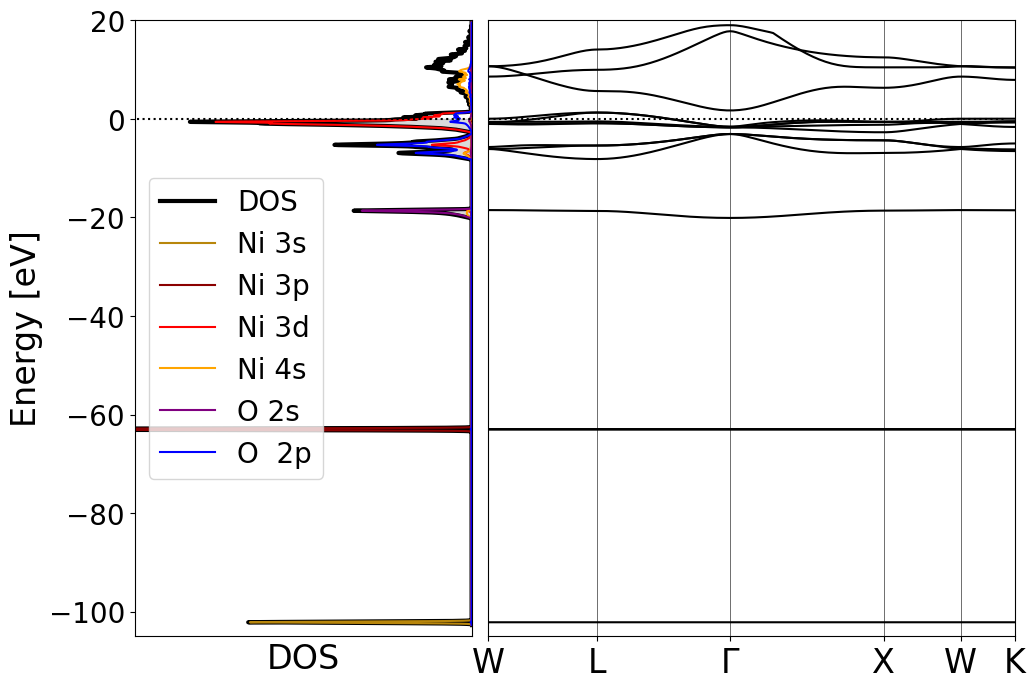

In [33]:
#-----------------------------------------------------------------
#                   Data loading
#-----------------------------------------------------------------

data_dos = np.loadtxt("pdos/NiO.pdos_tot").T
data_bands = np.loadtxt("bands.out.gnu").T.reshape(2, 16, 181) # 62    184

energies, pdos3s_Ni, ppdos3s_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#1(s)")
energies, pdos3p_Ni, ppdos3p_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#2(p)")
energies, pdos3d_Ni, ppdos3d_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#3(d)")
energies, pdos4s_Ni, ppdos4s_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#4(s)")

energies, pdos2s_O, ppdos2s_O =  data_loader("pdos/NiO.pdos_atm#2(O)_wfc#1(s)")
energies, pdos2p_O, ppdos2p_O =  data_loader("pdos/NiO.pdos_atm#2(O)_wfc#2(p)")

Efermi = 14.0223

Emax = 20
Emin = -105
dos_max = 10

#-----------------------------------------------------------------
#                           Plot
#-----------------------------------------------------------------
#----------------------   First figure   ------------------------#

fig, ax = plt.subplots(1,2, figsize = (10, 8))
fig.subplots_adjust(wspace=-0.16)  # espace horizontal et vertical entre les subplots
box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width * 1.25, box.height]) 
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width / 1.25, box.height])


# DOS
mask = data_dos[0] - Efermi < 0
ax[0].plot(data_dos[1], data_dos[0] - Efermi, "-", color = "black", linewidth = 3, label = "DOS")
ax[0].fill_betweenx(data_dos[0][mask] - Efermi, data_dos[1][mask], 0, color = "black", alpha = 0.15)

# PDOS
ax[0].plot(pdos3s_Ni, energies - Efermi, color = "darkgoldenrod", label = "Ni 3s")
ax[0].plot(pdos3p_Ni, energies - Efermi, color = "darkred", label = "Ni 3p")
ax[0].plot(pdos3d_Ni, energies - Efermi, color = "red", label = "Ni 3d")
ax[0].plot(pdos4s_Ni, energies - Efermi, color = "orange", label = "Ni 4s")

ax[0].plot(pdos2s_O, energies - Efermi, color = "purple", label = "O 2s")
ax[0].plot(pdos2p_O, energies - Efermi, color = "blue", label = "O  2p")

ax[0].plot([35, 0], [0, 0], ":", color = "black")

ax[0].set_xlim(dos_max, 0)
ax[0].set_ylim(Emin, Emax)
ax[0].set_xticks([])
ax[0].set_xlabel("DOS", fontsize = 24)
ax[0].set_ylabel("Energy [eV]", fontsize = 24)

ax[0].tick_params(axis='both', labelsize=20)
ax[0].legend(fontsize = 20)

#---------------------   Second figure  -------------------------#

for i in range(len(data_bands[0, :])):
    ax[1].plot(data_bands[0, i], data_bands[1, i] - Efermi, "-", color = "black")
ax[1].set_ylim(Emin, Emax)
ax[1].set_xlim(data_bands[0,0,0], data_bands[0,0,-1])

sym_kpoints = [0.0, 0.7071, 1.5731, 2.5731, 3.0731, 3.4267]
sym_kpoints_name = ["W", "L", "$\Gamma$", "X", "W", "K"]

ax[1].plot([0, 3.3698], [0, 0], ":", color = "black")                                             # fermi
for i in range(len(sym_kpoints)):
    ax[1].plot([sym_kpoints[i], sym_kpoints[i]], [Emin, Emax], color = "black", linewidth = 0.4)     # lignes verticales

ax[1].set_xticks(sym_kpoints)               
ax[1].set_xticklabels(sym_kpoints_name, fontsize = 24) 
ax[1].set_yticks([])   

fig.savefig("dos_vs_bands_out.pdf", bbox_inches='tight', transparent=True)
plt.show()

<>:74: SyntaxWarning: invalid escape sequence '\G'
<>:74: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_16467/2864258477.py:74: SyntaxWarning: invalid escape sequence '\G'
  sym_kpoints_name = ["W", "L", "$\Gamma$", "X", "W", "K"]


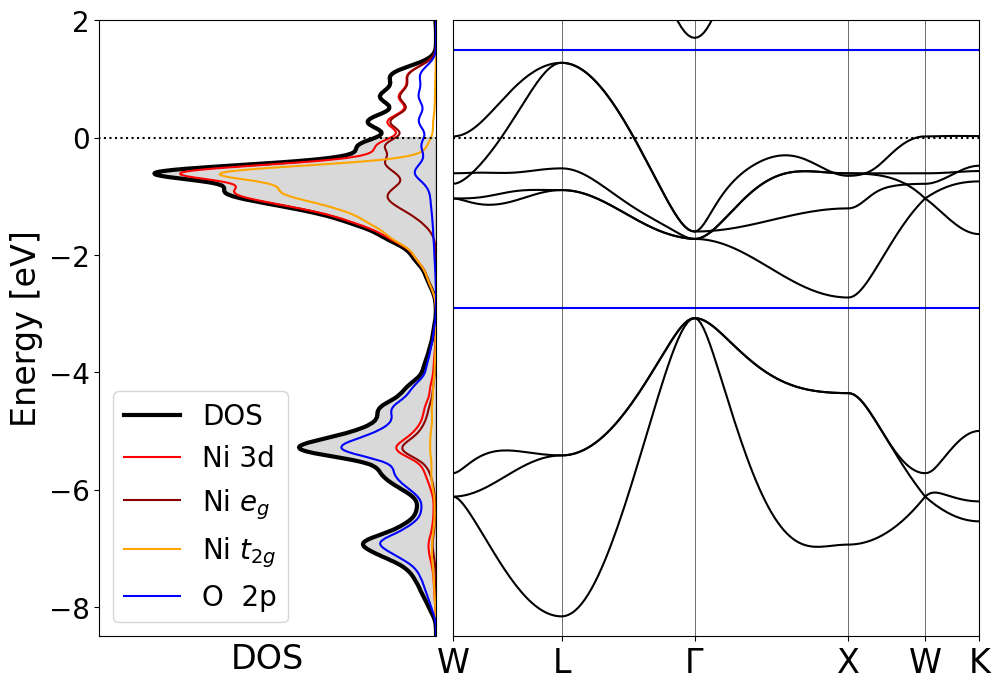

In [50]:
#-----------------------------------------------------------------
#                   Data loading
#-----------------------------------------------------------------

data_dos = np.loadtxt("pdos/NiO.pdos_tot").T
data_bands = np.loadtxt("bands.out.gnu").T.reshape(2, 16, 181) # 62    184

energies, pdos3s_Ni, ppdos3s_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#1(s)")
energies, pdos3p_Ni, ppdos3p_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#2(p)")
energies, pdos3d_Ni, ppdos3d_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#3(d)")
energies, pdos4s_Ni, ppdos4s_Ni =  data_loader("pdos/NiO.pdos_atm#1(Ni)_wfc#4(s)")

energies, pdos2s_O, ppdos2s_O =  data_loader("pdos/NiO.pdos_atm#2(O)_wfc#1(s)")
energies, pdos2p_O, ppdos2p_O =  data_loader("pdos/NiO.pdos_atm#2(O)_wfc#2(p)")

Efermi = 14.0223

Emax = 2
Emin = -8.5
dos_max = 10

#-----------------------------------------------------------------
#                           Plot
#-----------------------------------------------------------------
#----------------------   First figure   ------------------------#

fig, ax = plt.subplots(1,2, figsize = (10, 8))
fig.subplots_adjust(wspace=-0.16)  # espace horizontal et vertical entre les subplots
box = ax[1].get_position()
ax[1].set_position([box.x0, box.y0, box.width * 1.25, box.height]) 
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width / 1.25, box.height])


# DOS
mask = data_dos[0] - Efermi < 0
ax[0].plot(data_dos[1], data_dos[0] - Efermi, "-", color = "black", linewidth = 3, label = "DOS")
ax[0].fill_betweenx(data_dos[0][mask] - Efermi, data_dos[1][mask], 0, color = "black", alpha = 0.15)

# PDOS
#ax[0].plot(pdos3s_Ni, energies - Efermi, color = "darkgoldenrod", label = "Ni 3s")
#ax[0].plot(pdos3p_Ni, energies - Efermi, color = "darkred", label = "Ni 3p")
ax[0].plot(pdos3d_Ni, energies - Efermi, color = "red", label = "Ni 3d")
ax[0].plot(2*ppdos3d_Ni[:,0], energies - Efermi, color = "darkred", label = r"Ni $e_g$")
ax[0].plot(3*ppdos3d_Ni[:,1], energies - Efermi, color = "orange", label = r"Ni $t_{2g}$")

#ax[0].plot(pdos4s_Ni, energies - Efermi, color = "orange", label = "Ni 4s")

# ax[0].plot(pdos2s_O, energies - Efermi, color = "purple", label = "O 2s")
ax[0].plot(pdos2p_O, energies - Efermi, color = "blue", label = "O  2p")

ax[0].plot([35, 0], [0, 0], ":", color = "black")

ax[0].set_xlim(dos_max, 0)
ax[0].set_ylim(Emin, Emax)
ax[0].set_xticks([])
ax[0].set_xlabel("DOS", fontsize = 24)
ax[0].set_ylabel("Energy [eV]", fontsize = 24)

ax[0].tick_params(axis='both', labelsize=20)
ax[0].legend(fontsize = 20)

#---------------------   Second figure  -------------------------#

for i in range(len(data_bands[0, :])):
    ax[1].plot(data_bands[0, i], data_bands[1, i] - Efermi, "-", color = "black")
ax[1].set_ylim(Emin, Emax)
ax[1].set_xlim(data_bands[0,0,0], data_bands[0,0,-1])

ax[1].plot([0, sym_kpoints[-1]], [1.5, 1.5], "-", color = "blue")
ax[1].plot([0, sym_kpoints[-1]], [-2.9, -2.9], "-", color = "blue")

sym_kpoints = [0.0, 0.7071, 1.5731, 2.5731, 3.0731, 3.4267]
sym_kpoints_name = ["W", "L", "$\Gamma$", "X", "W", "K"]

ax[1].plot([0, sym_kpoints[-1]], [0, 0], ":", color = "black")                                             # fermi
for i in range(len(sym_kpoints)):
    ax[1].plot([sym_kpoints[i], sym_kpoints[i]], [Emin, Emax], color = "black", linewidth = 0.4)     # lignes verticales

ax[1].set_xticks(sym_kpoints)               
ax[1].set_xticklabels(sym_kpoints_name, fontsize = 24) 
ax[1].set_yticks([])   

fig.savefig("dos_vs_bands_in.pdf", bbox_inches='tight', transparent=True)
plt.show()